# 2D Ferromagnetic Ising Model Simulation with Metropolis Monte Carlo

In this guide, we generate finite-size scaling dataset for the **two-dimensional ferromagnetic Ising model** on a square lattice from scratch using **vectorized Metropolis Monte Carlo** and **Jackknife error estimation**.

By the end of this tutorial, you will have a clear understanding of:
1. The 2D Ising Hamiltonian and the Binder parameter $U(T, L)$.
2. Vectorized checkerboard (sublattice) Metropolis sampling in NumPy.
3. Jackknife resampling for evaluating statistical errors of non-linear ratios.
4. How to format and save the simulation dataset for analysis with `jaxfss`.

## 1. Theoretical Background

The standard 2D ferromagnetic Ising model on an $L \times L$ square lattice with periodic boundary conditions is described by the Hamiltonian:

$$
H = -J \sum_{\langle i, j \rangle} \sigma_i \sigma_j, \quad \sigma_i \in \{-1, +1\}
$$

where $\langle i, j \rangle$ denotes nearest-neighbor pairs, and we set $J = 1$.

### Exact Critical Temperature
Onsager's exact solution provides the critical temperature $T_{\mathrm{c}}$ (or inverse critical temperature $K_{\mathrm{c}} = J / k_{\mathrm{B}} T_{\mathrm{c}}$):

$$
T_{\mathrm{c}} = \frac{2}{\ln(1 + \sqrt{2})} \approx 2.269185, \quad K_{\mathrm{c}} = \frac{1}{T_{\mathrm{c}}} \approx 0.4406868
$$

### The Binder Parameter (Binder Cumulant)
The fourth-order Binder parameter $U(T, L)$ is defined as:

$$
U(T, L) = 1 - \frac{\langle M^4 \rangle}{3 \langle M^2 \rangle^2}
$$

where $M = \sum_{i=1}^N \sigma_i$ is the total magnetization. In the thermodynamic limit:
* $T < T_{\mathrm{c}}$ (ordered phase): $U \to 2/3 \approx 0.6667$
* $T > T_{\mathrm{c}}$ (disordered phase): $U \to 0$
* At $T = T_{\mathrm{c}}$: $U(T_{\mathrm{c}}, L)$ is scale-invariant (all finite-size curves cross at $T_{\mathrm{c}}$).

The finite-size scaling relation for $U$ has anomalous dimension $c_2 = 0$:

$$
U(T, L) = F\left[ (T - T_{\mathrm{c}}) L^{1/\nu} \right] = F\left[ (K - K_{\mathrm{c}}) L^{c_1} \right]
$$

with exact 2D exponent $\nu = 1 \implies c_1 = 1.0$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import jaxfss

## 2. Vectorized Checkerboard Metropolis Monte Carlo

In a square lattice, sites can be partitioned into two independent sublattices (like black and white squares of a chessboard: $(x + y) \pmod 2 == 0$ and $(x + y) \pmod 2 == 1$).

Because nearest neighbors of any "even" site are strictly "odd" sites, all even sites can be updated **simultaneously in parallel** without race conditions, followed by updating all odd sites.

In [2]:
def simulate_ising_chain(
    L: int,
    inv_T: float,
    n_thermalization: int = 500,
    n_measurements: int = 2000,
    sample_interval: int = 5,
    seed: int = 0,
) -> np.ndarray:
    """Sample magnetization M = sum(sigma) using vectorized checkerboard Metropolis."""
    rng = np.random.default_rng(seed)
    spins = rng.choice([-1, 1], size=(L, L)).astype(np.int8)
    
    # Sublattice masks
    i, j = np.meshgrid(np.arange(L), np.arange(L), indexing="ij")
    mask_even = (i + j) % 2 == 0
    mask_odd = ~mask_even
    
    def sweep():
        for mask in (mask_even, mask_odd):
            # Sum of 4 nearest neighbors with periodic boundary conditions
            nn_sum = (
                np.roll(spins, 1, axis=0)
                + np.roll(spins, -1, axis=0)
                + np.roll(spins, 1, axis=1)
                + np.roll(spins, -1, axis=1)
            )
            dE = 2 * spins * nn_sum
            # Acceptance probability for dE > 0
            prob = np.exp(-inv_T * dE)
            accept = (dE <= 0) | (rng.random((L, L)) < prob)
            spins[mask & accept] *= -1

    # Thermalization sweeps
    for _ in range(n_thermalization):
        sweep()

    # Measurement sweeps
    magnetizations = []
    for step in range(n_measurements * sample_interval):
        sweep()
        if step % sample_interval == 0:
            magnetizations.append(float(np.sum(spins)))

    return np.array(magnetizations)

## 3. Jackknife Error Estimation for Binder Parameter

The Binder cumulant $U = 1 - \frac{\langle M^4 \rangle}{3 \langle M^2 \rangle^2}$ is a ratio of non-linear averages. Standard propagation of error is biased, so we use the **Jackknife resampling** method.

In [3]:
def compute_binder_jackknife(magnetizations: np.ndarray, n_bins: int = 20) -> tuple[float, float]:
    """Compute Binder parameter and statistical error using Jackknife resampling with binning."""
    # Group into n_bins blocks to eliminate autocorrelation
    n_total = len(magnetizations)
    bin_size = n_total // n_bins
    m_binned = magnetizations[: n_bins * bin_size].reshape(n_bins, bin_size)
    
    # Bin averages of M^2 and M^4
    m2_bins = np.mean(m_binned**2, axis=1)
    m4_bins = np.mean(m_binned**4, axis=1)
    
    # Overall averages
    m2_mean = np.mean(m2_bins)
    m4_mean = np.mean(m4_bins)
    u_full = 1.0 - m4_mean / (3.0 * (m2_mean**2))
    
    # Jackknife pseudo-values (leaving out one bin at a time)
    u_jack = []
    for b in range(n_bins):
        m2_sub = (np.sum(m2_bins) - m2_bins[b]) / (n_bins - 1)
        m4_sub = (np.sum(m4_bins) - m4_bins[b]) / (n_bins - 1)
        u_jack.append(1.0 - m4_sub / (3.0 * (m2_sub**2)))
        
    u_jack = np.array(u_jack)
    # Jackknife standard error formula
    u_err = np.sqrt((n_bins - 1) * np.mean((u_jack - np.mean(u_jack)) ** 2))
    return float(u_full), float(u_err)

## 4. Multi-Size Simulation and Binder Crossing

We simulate three lattice sizes $L \in \{16, 32, 64\}$ over a grid of inverse temperatures $K = J / k_{\mathrm{B}} T$ around $K_{\mathrm{c}} \approx 0.4406868$.

In [4]:
L_list = [16, 32, 64]
inv_T_values = np.linspace(0.42, 0.46, 17)

results = {}
print("Running 2D Ising simulation...")
t_start = time.time()

for L in L_list:
    u_vals, u_errs = [], []
    for k_idx, inv_T in enumerate(inv_T_values):
        m_chain = simulate_ising_chain(
            L=L,
            inv_T=inv_T,
            n_thermalization=400,
            n_measurements=1500,
            sample_interval=3,
            seed=100 * L + k_idx,
        )
        u, u_err = compute_binder_jackknife(m_chain, n_bins=15)
        u_vals.append(u)
        u_errs.append(u_err)
    results[L] = (np.array(u_vals), np.array(u_errs))
    print(f"  L = {L:2d} completed in {time.time() - t_start:.2f}s")

print(f"Total simulation completed in {time.time() - t_start:.2f}s.")

Running 2D Ising simulation...


  L = 16 completed in 4.07s


  L = 32 completed in 9.95s


  L = 64 completed in 21.97s
Total simulation completed in 21.97s.


Plot the Binder ratio curves. All curves cross at the critical coupling $K_{\mathrm{c}} \approx 0.4406868$.

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/var/folders/g6/3yjn6zvx14s3q4k28w8d78fw0000gn/T/ipykernel_2412/1662117723.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.axvline(K_c_exact, color="black", linestyle=":", label=f"Exact $K_{{\mathrm{{c}}}} = {K_c_exact:.5f}$")


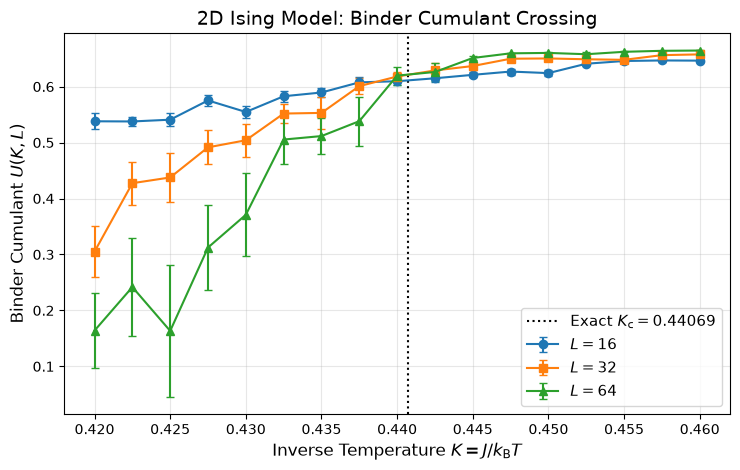

In [5]:
plt.figure(figsize=(7.5, 4.8))
markers = ["o", "s", "^"]
K_c_exact = 0.5 * np.log(1 + np.sqrt(2))

for (L, (u_vals, u_errs)), m in zip(results.items(), markers):
    plt.errorbar(inv_T_values, u_vals, yerr=u_errs, fmt=f"{m}-", label=f"$L = {L}$", capsize=3, lw=1.5)

plt.axvline(K_c_exact, color="black", linestyle=":", label=f"Exact $K_{{\mathrm{{c}}}} = {K_c_exact:.5f}$")
plt.xlabel(r"Inverse Temperature $K = J / k_{\mathrm{B}} T$", fontsize=12)
plt.ylabel(r"Binder Cumulant $U(K, L)$", fontsize=12)
plt.title("2D Ising Model: Binder Cumulant Crossing", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Exporting Dataset for `jaxfss`

We save our simulated Binder cumulant data to `ising_custom.txt` in the standard tabular format:
```
L  K  U  U_err
```

In [6]:
output_rows = []
for L, (u_vals, u_errs) in results.items():
    for k_val, u, err in zip(inv_T_values, u_vals, u_errs):
        output_rows.append([L, k_val, u, err])

output_data = np.array(output_rows)
output_path = "ising_custom.txt"

np.savetxt(
    output_path,
    output_data,
    fmt=["%d", "%.8f", "%.8f", "%.8f"],
    header="L K U U_err"
)
print(f"Saved {len(output_data)} rows to {output_path}.")

# Verify loading with jaxfss
loaded_dataset = jaxfss.CriticalData.from_file(output_path)
print(f"Successfully loaded into jaxfss: {loaded_dataset}")
print(f"System sizes in dataset: {np.unique(loaded_dataset.Ls)}")

Saved 51 rows to ising_custom.txt.


Successfully loaded into jaxfss: jaxfss.CriticalData(n_data=51)
System sizes in dataset: [16. 32. 64.]


## Summary

We have implemented a fast, vectorized 2D Ising Metropolis Monte Carlo simulation, computed Binder cumulants with Jackknife error estimates, verified the universal curve crossing at $T_{\mathrm{c}}$, and exported the data ready for `jaxfss` Finite-Size Scaling analysis.